In [61]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("QVI_data.csv")

In [3]:
data

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream
...,...,...,...,...,...,...,...,...,...,...,...,...
264829,2370701,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,210,GRNWVES,YOUNG FAMILIES,Mainstream
264830,2370751,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Premium
264831,2370961,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165,TYRRELLS,OLDER FAMILIES,Budget
264832,2370961,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,300,OLD,OLDER FAMILIES,Budget


In [4]:
data.columns

Index(['LYLTY_CARD_NBR', 'DATE', 'STORE_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'BRAND', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='object')

In [5]:
#Converting the DATE type(object) to type datetime
data["DATE"] = pd.to_datetime(data["DATE"])

In [6]:
print(data['DATE'].dtype)

datetime64[ns]


In [7]:
#creating an column (year_month)
data['YEAR_MONTH'] = data['DATE'].dt.to_period('M')

In [8]:
data[['DATE','YEAR_MONTH']].head()

,DATE,YEAR_MONTH
0,2018-10-17,2018-10
1,2018-09-16,2018-09
2,2019-03-07,2019-03
3,2019-03-08,2019-03
4,2018-11-02,2018-11


In [9]:
#creating a monthly store metrics for each stores
monthly_metrics = (
    data.groupby(["STORE_NBR", "YEAR_MONTH"])
      .agg(
          TOTAL_SALES=("TOT_SALES", "sum"),
          TOTAL_CUSTOMERS=("LYLTY_CARD_NBR", "nunique"),
          TOTAL_TXNS=("TXN_ID", "nunique")
      )
      .reset_index()
)

In [10]:
#adding average transactions per customer
monthly_metrics["TXN_PER_CUSTOMER"] = (
    monthly_metrics["TOTAL_TXNS"] /
    monthly_metrics["TOTAL_CUSTOMERS"]
)

In [11]:
monthly_metrics

,STORE_NBR,YEAR_MONTH,TOTAL_SALES,TOTAL_CUSTOMERS,TOTAL_TXNS,TXN_PER_CUSTOMER
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739
...,...,...,...,...,...,...
3164,272,2019-02,395.5,45,48,1.066667
3165,272,2019-03,442.3,50,53,1.060000
3166,272,2019-04,445.1,54,55,1.018519
3167,272,2019-05,314.6,34,40,1.176471


In [12]:
monthly_metrics["YEAR_MONTH"].unique()

<PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01',
 '2019-02', '2019-03', '2019-04', '2019-05', '2019-06']
Length: 12, dtype: period[M]

In [13]:
pre_trial = monthly_metrics[
    monthly_metrics["YEAR_MONTH"] < "2019-02"
]

In [14]:
'''pre_trial = monthly_metrics[
    monthly_metrics["YEAR_MONTH"] < pd.Period("2019-02")
]'''

'pre_trial = monthly_metrics[\n    monthly_metrics["YEAR_MONTH"] < pd.Period("2019-02")\n]'

In [15]:
#focuing on trial stores only
trial_stores = [77, 86, 88]

pre_trial[
    pre_trial["STORE_NBR"].isin(trial_stores)
].head()

,STORE_NBR,YEAR_MONTH,TOTAL_SALES,TOTAL_CUSTOMERS,TOTAL_TXNS,TXN_PER_CUSTOMER
880,77,2018-07,296.8,51,55,1.078431
881,77,2018-08,255.5,47,48,1.021277
882,77,2018-09,225.2,42,44,1.047619
883,77,2018-10,204.5,37,38,1.027027
884,77,2018-11,245.3,41,44,1.073171


In [16]:
pre_trial.groupby("STORE_NBR")["YEAR_MONTH"].count().sort_values()

,YEAR_MONTH
STORE_NBR,
211,1
206,1
85,1
193,1
76,1
...,...
269,7
270,7
271,7


In [19]:
#Choosing only that stores which are eligible
store_counts = (
    pre_trial.groupby("STORE_NBR")["YEAR_MONTH"]
    .count()
)

eligible_stores = store_counts[
    store_counts == 7
].index

pre_trial = pre_trial[
    pre_trial["STORE_NBR"].isin(eligible_stores)
]

In [22]:
# Correlation function
def calculate_correlation(data, trial_store, metric):
    """
    Calculate Pearson correlation between a trial store
    and every other store for a given metric.
    """
    # Trial store data
    trial = data[data["STORE_NBR"] == trial_store][
        ["YEAR_MONTH", metric]
    ].rename(columns={metric: "TRIAL_METRIC"})

    correlations = []
    for store in data["STORE_NBR"].unique():

        if store == trial_store:
            continue
        control = data[data["STORE_NBR"] == store][
            ["YEAR_MONTH", metric]
        ].rename(columns={metric: "CONTROL_METRIC"})
        merged = pd.merge(
            trial,
            control,
            on="YEAR_MONTH",
            how="inner"
        )
        if len(merged) < 2:
            continue
        corr = merged["TRIAL_METRIC"].corr(
            merged["CONTROL_METRIC"]
        )
        correlations.append({
            "Trial_Store": trial_store,
            "Control_Store": store,
            "Metric": metric,
            "Correlation": corr
        })
    return pd.DataFrame(correlations)

In [23]:
sales_corr = calculate_correlation(
    pre_trial,
    77,
    "TOTAL_SALES"
)

sales_corr.sort_values(
    "Correlation",
    ascending=False
).head(10)

,Trial_Store,Control_Store,Metric,Correlation
67,77,71,TOTAL_SALES,0.914106
220,77,233,TOTAL_SALES,0.903774
110,77,119,TOTAL_SALES,0.867664
15,77,17,TOTAL_SALES,0.842668
2,77,3,TOTAL_SALES,0.806644
38,77,41,TOTAL_SALES,0.783232
46,77,50,TOTAL_SALES,0.763866
148,77,157,TOTAL_SALES,0.735893
153,77,162,TOTAL_SALES,0.729740
243,77,257,TOTAL_SALES,0.724927


In [24]:
customer_corr = calculate_correlation(
    pre_trial,
    77,
    "TOTAL_CUSTOMERS"
)

customer_corr.sort_values(
    "Correlation",
    ascending=False
).head()

,Trial_Store,Control_Store,Metric,Correlation
220,77,233,TOTAL_CUSTOMERS,0.990358
110,77,119,TOTAL_CUSTOMERS,0.983267
240,77,254,TOTAL_CUSTOMERS,0.916208
105,77,113,TOTAL_CUSTOMERS,0.901348
78,77,84,TOTAL_CUSTOMERS,0.858571


In [25]:
def calculate_magnitude(data, trial_store, metric):

    trial = data[data["STORE_NBR"] == trial_store][
        ["YEAR_MONTH", metric]
    ].rename(columns={metric: "TRIAL_METRIC"})

    similarity = []

    for store in data["STORE_NBR"].unique():

        if store == trial_store:
            continue

        control = data[data["STORE_NBR"] == store][
            ["YEAR_MONTH", metric]
        ].rename(columns={metric: "CONTROL_METRIC"})

        merged = pd.merge(
            trial,
            control,
            on="YEAR_MONTH"
        )

        if len(merged) < 2:
            continue

        distance = (
            abs(
                merged["TRIAL_METRIC"] -
                merged["CONTROL_METRIC"]
            )
        ).mean()

        similarity.append({
            "Trial_Store": trial_store,
            "Control_Store": store,
            "Distance": distance
        })

    similarity = pd.DataFrame(similarity)

    min_dist = similarity["Distance"].min()
    max_dist = similarity["Distance"].max()

    similarity["Magnitude"] = (
        1 -
        (
            similarity["Distance"] - min_dist
        ) /
        (
            max_dist - min_dist
        )
    )

    return similarity

In [26]:
sales_mag = calculate_magnitude(
    pre_trial,
    77,
    "TOTAL_SALES"
)

sales_mag.sort_values(
    "Magnitude",
    ascending=False
).head()

,Trial_Store,Control_Store,Distance,Magnitude
220,77,233,18.828571,1.000000
241,77,255,28.571429,0.991889
179,77,188,31.100000,0.989784
49,77,53,32.471429,0.988642
122,77,131,33.042857,0.988167


In [27]:
comparison = pd.merge(
    sales_corr[
        ["Control_Store","Correlation"]
    ],
    sales_mag[
        ["Control_Store","Magnitude"]
    ],
    on="Control_Store"
)

comparison["Final_Score"] = (
    comparison["Correlation"] +
    comparison["Magnitude"]
) / 2

comparison.sort_values(
    "Final_Score",
    ascending=False
).head(10)

,Control_Store,Correlation,Magnitude,Final_Score
220,233,0.903774,1.000000,0.951887
38,41,0.783232,0.977927,0.880579
46,50,0.763866,0.986775,0.875320
15,17,0.842668,0.886125,0.864397
107,115,0.689159,0.942700,0.815929
158,167,0.657110,0.971148,0.814129
251,265,0.639759,0.975489,0.807624
221,234,0.696325,0.896056,0.796190
49,53,0.532764,0.988642,0.760703
78,84,0.684348,0.832583,0.758465


In [28]:
# for 77 the control store store is 233

In [31]:
sales_corr = calculate_correlation(
    pre_trial,
    86,
    "TOTAL_SALES"
)

sales_corr.sort_values(
    "Correlation",
    ascending=False
).head(10)

,Trial_Store,Control_Store,Metric,Correlation
146,86,155,TOTAL_SALES,0.877882
123,86,132,TOTAL_SALES,0.846517
227,86,240,TOTAL_SALES,0.825066
209,86,222,TOTAL_SALES,0.795075
101,86,109,TOTAL_SALES,0.788300
129,86,138,TOTAL_SALES,0.759864
188,86,198,TOTAL_SALES,0.748794
106,86,114,TOTAL_SALES,0.734415
20,86,22,TOTAL_SALES,0.722966
5,86,6,TOTAL_SALES,0.721892


In [33]:
customer_corr = calculate_correlation(
    pre_trial,
    86,
    "TOTAL_CUSTOMERS"
)

customer_corr.sort_values(
    "Correlation",
    ascending=False
).head()

,Trial_Store,Control_Store,Metric,Correlation
146,86,155,TOTAL_CUSTOMERS,0.942876
106,86,114,TOTAL_CUSTOMERS,0.855339
246,86,260,TOTAL_CUSTOMERS,0.846502
167,86,176,TOTAL_CUSTOMERS,0.796380
101,86,109,TOTAL_CUSTOMERS,0.770778


In [34]:
sales_mag = calculate_magnitude(
    pre_trial,
    86,
    "TOTAL_SALES"
)

sales_mag.sort_values(
    "Magnitude",
    ascending=False
).head()

,Trial_Store,Control_Store,Distance,Magnitude
101,86,109,31.607143,1.000000
146,86,155,32.464286,0.998964
209,86,222,35.864286,0.994853
212,86,225,37.535714,0.992833
216,86,229,45.864286,0.982764


In [35]:
comparison = pd.merge(
    sales_corr[
        ["Control_Store","Correlation"]
    ],
    sales_mag[
        ["Control_Store","Magnitude"]
    ],
    on="Control_Store"
)

comparison["Final_Score"] = (
    comparison["Correlation"] +
    comparison["Magnitude"]
) / 2

comparison.sort_values(
    "Final_Score",
    ascending=False
).head(10)

,Control_Store,Correlation,Magnitude,Final_Score
146,155,0.877882,0.998964,0.938423
209,222,0.795075,0.994853,0.894964
101,109,0.788300,1.000000,0.894150
129,138,0.759864,0.959103,0.859483
106,114,0.734415,0.955087,0.844751
255,269,0.697055,0.934267,0.815661
98,106,0.678684,0.943602,0.811143
212,225,0.617533,0.992833,0.805183
119,128,0.654929,0.895719,0.775324
74,79,0.668748,0.861479,0.765113


In [36]:
# 86 the control store is 155

In [37]:
sales_corr = calculate_correlation(
    pre_trial,
    88,
    "TOTAL_SALES"
)

sales_corr.sort_values(
    "Correlation",
    ascending=False
).head(10)

,Trial_Store,Control_Store,Metric,Correlation
150,88,159,TOTAL_SALES,0.903186
194,88,204,TOTAL_SALES,0.885774
125,88,134,TOTAL_SALES,0.864293
0,88,1,TOTAL_SALES,0.813636
239,88,253,TOTAL_SALES,0.811838
84,88,91,TOTAL_SALES,0.776688
57,88,61,TOTAL_SALES,0.748929
169,88,178,TOTAL_SALES,0.731857
179,88,188,TOTAL_SALES,0.716752
152,88,161,TOTAL_SALES,0.706581


In [38]:
customer_corr = calculate_correlation(
    pre_trial,
    88,
    "TOTAL_CUSTOMERS"
)

customer_corr.sort_values(
    "Correlation",
    ascending=False
).head()

,Trial_Store,Control_Store,Metric,Correlation
224,88,237,TOTAL_CUSTOMERS,0.947326
12,88,14,TOTAL_CUSTOMERS,0.942976
169,88,178,TOTAL_CUSTOMERS,0.939466
32,88,35,TOTAL_CUSTOMERS,0.899594
105,88,113,TOTAL_CUSTOMERS,0.862632


In [39]:
sales_mag = calculate_magnitude(
    pre_trial,
    88,
    "TOTAL_SALES"
)

sales_mag.sort_values(
    "Magnitude",
    ascending=False
).head()

,Trial_Store,Control_Store,Distance,Magnitude
224,88,237,58.428571,1.000000
193,88,203,66.100000,0.993943
37,88,40,83.028571,0.980578
189,88,199,104.457143,0.963659
156,88,165,113.057143,0.956869


In [40]:
comparison = pd.merge(
    sales_corr[
        ["Control_Store","Correlation"]
    ],
    sales_mag[
        ["Control_Store","Magnitude"]
    ],
    on="Control_Store"
)

comparison["Final_Score"] = (
    comparison["Correlation"] +
    comparison["Magnitude"]
) / 2

comparison.sort_values(
    "Final_Score",
    ascending=False
).head(10)

,Control_Store,Correlation,Magnitude,Final_Score
116,125,0.624109,0.890950,0.757529
193,203,0.508001,0.993943,0.750972
84,91,0.776688,0.690439,0.733564
6,7,0.649657,0.812646,0.731151
169,178,0.731857,0.725911,0.728884
191,201,0.492735,0.912115,0.702425
98,106,0.644724,0.730643,0.687683
74,79,0.576960,0.793432,0.685196
224,237,0.308479,1.000000,0.654240
146,155,0.600771,0.699315,0.650043


In [41]:
# for 88 the control store is 125

In [42]:
comparison.sort_values(
    "Final_Score",
    ascending=False
).head(10)

,Control_Store,Correlation,Magnitude,Final_Score
116,125,0.624109,0.890950,0.757529
193,203,0.508001,0.993943,0.750972
84,91,0.776688,0.690439,0.733564
6,7,0.649657,0.812646,0.731151
169,178,0.731857,0.725911,0.728884
191,201,0.492735,0.912115,0.702425
98,106,0.644724,0.730643,0.687683
74,79,0.576960,0.793432,0.685196
224,237,0.308479,1.000000,0.654240
146,155,0.600771,0.699315,0.650043


In [43]:
#trail period data
trial_period = monthly_metrics[
    (monthly_metrics["YEAR_MONTH"] >= pd.Period("2019-02")) &
    (monthly_metrics["YEAR_MONTH"] <= pd.Period("2019-04"))
]

In [47]:
# trail store vs control store comparsion for 77 and 233
trial_77 = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 77
]

control_233 = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 233
]
compare_77 = pd.merge(
    trial_77,
    control_233,
    on="YEAR_MONTH",
    suffixes=("_TRIAL", "_CONTROL")
)

compare_77

,STORE_NBR_TRIAL,YEAR_MONTH,TOTAL_SALES_TRIAL,TOTAL_CUSTOMERS_TRIAL,TOTAL_TXNS_TRIAL,TXN_PER_CUSTOMER_TRIAL,STORE_NBR_CONTROL,TOTAL_SALES_CONTROL,TOTAL_CUSTOMERS_CONTROL,TOTAL_TXNS_CONTROL,TXN_PER_CUSTOMER_CONTROL
0,77,2018-07,296.8,51,55,1.078431,233,290.7,51,54,1.058824
1,77,2018-08,255.5,47,48,1.021277,233,285.9,48,50,1.041667
2,77,2018-09,225.2,42,44,1.047619,233,228.6,42,45,1.071429
3,77,2018-10,204.5,37,38,1.027027,233,185.7,35,36,1.028571
4,77,2018-11,245.3,41,44,1.073171,233,211.6,40,41,1.025000
5,77,2018-12,267.3,46,48,1.043478,233,279.8,47,50,1.063830
6,77,2019-01,204.4,35,39,1.114286,233,177.5,35,35,1.000000
7,77,2019-02,235.0,45,45,1.000000,233,244.0,45,47,1.044444
8,77,2019-03,278.5,50,55,1.100000,233,199.1,40,41,1.025000
9,77,2019-04,263.5,47,48,1.021277,233,158.6,30,32,1.066667


In [48]:
# trail store vs control store comparsion for 86 and 155
trial_86 = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 86
]

control_155 = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 155
]
compare_86 = pd.merge(
    trial_86,
    control_155,
    on="YEAR_MONTH",
    suffixes=("_TRIAL", "_CONTROL")
)

compare_86

,STORE_NBR_TRIAL,YEAR_MONTH,TOTAL_SALES_TRIAL,TOTAL_CUSTOMERS_TRIAL,TOTAL_TXNS_TRIAL,TXN_PER_CUSTOMER_TRIAL,STORE_NBR_CONTROL,TOTAL_SALES_CONTROL,TOTAL_CUSTOMERS_CONTROL,TOTAL_TXNS_CONTROL,TXN_PER_CUSTOMER_CONTROL
0,86,2018-07,892.20,99,126,1.272727,155,924.60,101,123,1.217822
1,86,2018-08,764.05,94,110,1.170213,155,782.70,91,119,1.307692
2,86,2018-09,914.60,103,128,1.242718,155,1014.40,103,144,1.398058
3,86,2018-10,948.40,109,138,1.266055,155,963.80,108,136,1.259259
4,86,2018-11,918.00,100,125,1.250000,155,898.80,101,133,1.316832
5,86,2018-12,841.20,98,120,1.224490,155,849.80,97,120,1.237113
6,86,2019-01,841.40,94,129,1.372340,155,874.60,96,125,1.302083
7,86,2019-02,913.20,107,138,1.289720,155,891.20,95,125,1.315789
8,86,2019-03,1026.80,115,140,1.217391,155,804.40,94,118,1.255319
9,86,2019-04,848.20,105,126,1.200000,155,844.60,99,120,1.212121


In [49]:
# trail store vs control store comparsion for 88 and 125
trial_88 = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 88
]

control_125 = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 125
]
compare_88 = pd.merge(
    trial_88,
    control_125,
    on="YEAR_MONTH",
    suffixes=("_TRIAL", "_CONTROL")
)

compare_88

,STORE_NBR_TRIAL,YEAR_MONTH,TOTAL_SALES_TRIAL,TOTAL_CUSTOMERS_TRIAL,TOTAL_TXNS_TRIAL,TXN_PER_CUSTOMER_TRIAL,STORE_NBR_CONTROL,TOTAL_SALES_CONTROL,TOTAL_CUSTOMERS_CONTROL,TOTAL_TXNS_CONTROL,TXN_PER_CUSTOMER_CONTROL
0,88,2018-07,1310.00,129,153,1.186047,125,1039.80,98,121,1.234694
1,88,2018-08,1323.80,131,158,1.206107,125,1114.75,111,132,1.189189
2,88,2018-09,1423.00,124,157,1.266129,125,1217.20,123,141,1.146341
3,88,2018-10,1352.40,123,155,1.260163,125,1120.70,111,125,1.126126
4,88,2018-11,1382.80,130,156,1.200000,125,1187.00,123,141,1.146341
5,88,2018-12,1325.20,126,148,1.174603,125,1218.60,119,138,1.159664
6,88,2019-01,1266.40,117,144,1.230769,125,1109.70,108,127,1.175926
7,88,2019-02,1370.20,124,153,1.233871,125,915.80,86,103,1.197674
8,88,2019-03,1477.20,134,169,1.261194,125,1235.40,121,141,1.165289
9,88,2019-04,1439.40,128,162,1.265625,125,1108.20,108,124,1.148148


In [56]:
#Statistical Test for 77

# for sales
trial_sales = compare_77[
    compare_77["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_SALES_TRIAL"]

control_sales = compare_77[
    compare_77["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_SALES_CONTROL"]

t_stat, p_value = ttest_ind(
    trial_sales,
    control_sales
)

print('T test for trail sales :',t_stat)
print('p value for control sales :',p_value)
print()


#for customers
trial_customers = compare_77[
    compare_77["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_CUSTOMERS_TRIAL"]

control_customers = compare_77[
    compare_77["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_CUSTOMERS_CONTROL"]

t_stat, p_value = ttest_ind(
    trial_customers,
    control_customers
)

print('T test for trail customers :',t_stat)
print('p value for control customers :',p_value)
print()


#for transactions per customers
trial_transaction = compare_77[
    compare_77["YEAR_MONTH"] >= pd.Period("2019-02")
]["TXN_PER_CUSTOMER_TRIAL"]

control_transaction = compare_77[
    compare_77["YEAR_MONTH"] >= pd.Period("2019-02")
]["TXN_PER_CUSTOMER_CONTROL"]

t_stat, p_value = ttest_ind(
    trial_transaction,
    control_transaction
)

print('T test for trail transaction per customers :',t_stat)
print('p value for control transaction per customers :',p_value)

T test for trail sales : 1.0590935477424306
p value for control sales : 0.32048413679130267

T test for trail customers : 1.0076877522384466
p value for control customers : 0.3431073698911317

T test for trail transaction per customers : -0.5179629957257171
p value for control transaction per customers : 0.6184997395977818


,STORE_NBR_TRIAL,YEAR_MONTH,TOTAL_SALES_TRIAL,TOTAL_CUSTOMERS_TRIAL,TOTAL_TXNS_TRIAL,TXN_PER_CUSTOMER_TRIAL,STORE_NBR_CONTROL,TOTAL_SALES_CONTROL,TOTAL_CUSTOMERS_CONTROL,TOTAL_TXNS_CONTROL,TXN_PER_CUSTOMER_CONTROL
0,77,2018-07,296.8,51,55,1.078431,233,290.7,51,54,1.058824
1,77,2018-08,255.5,47,48,1.021277,233,285.9,48,50,1.041667
2,77,2018-09,225.2,42,44,1.047619,233,228.6,42,45,1.071429
3,77,2018-10,204.5,37,38,1.027027,233,185.7,35,36,1.028571
4,77,2018-11,245.3,41,44,1.073171,233,211.6,40,41,1.025000
5,77,2018-12,267.3,46,48,1.043478,233,279.8,47,50,1.063830
6,77,2019-01,204.4,35,39,1.114286,233,177.5,35,35,1.000000
7,77,2019-02,235.0,45,45,1.000000,233,244.0,45,47,1.044444
8,77,2019-03,278.5,50,55,1.100000,233,199.1,40,41,1.025000
9,77,2019-04,263.5,47,48,1.021277,233,158.6,30,32,1.066667


In [59]:
#Statistical Test for 86

# for sales
trial_sales = compare_86[
    compare_86["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_SALES_TRIAL"]

control_sales = compare_86[
    compare_86["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_SALES_CONTROL"]

t_stat, p_value = ttest_ind(
    trial_sales,
    control_sales
)

print('T test for trail sales :',t_stat)
print('p value for control sales :',p_value)
print()


#for customers
trial_customers = compare_86[
    compare_86["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_CUSTOMERS_TRIAL"]

control_customers = compare_86[
    compare_86["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_CUSTOMERS_CONTROL"]

t_stat, p_value = ttest_ind(
    trial_customers,
    control_customers
)

print('T test for trail customers :',t_stat)
print('p value for control customers :',p_value)
print()


#for transactions per customers
trial_transaction = compare_86[
    compare_86["YEAR_MONTH"] >= pd.Period("2019-02")
]["TXN_PER_CUSTOMER_TRIAL"]

control_transaction = compare_86[
    compare_86["YEAR_MONTH"] >= pd.Period("2019-02")
]["TXN_PER_CUSTOMER_CONTROL"]

t_stat, p_value = ttest_ind(
    trial_transaction,
    control_transaction
)

print('T test for trail transaction per customers :',t_stat)
print('p value for control transaction per customers :',p_value)

T test for trail sales : 0.9914861460518972
p value for control sales : 0.35048565098844203

T test for trail customers : 2.264554068289191
p value for control customers : 0.05334189534187311

T test for trail transaction per customers : -1.6799400467273102
p value for control transaction per customers : 0.13148054286474384


In [60]:
#Statistical Test for 88

# for sales
trial_sales = compare_88[
    compare_88["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_SALES_TRIAL"]

control_sales = compare_88[
    compare_88["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_SALES_CONTROL"]

t_stat, p_value = ttest_ind(
    trial_sales,
    control_sales
)

print('T test for trail sales :',t_stat)
print('p value for control sales :',p_value)
print()


#for customers
trial_customers = compare_88[
    compare_88["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_CUSTOMERS_TRIAL"]

control_customers = compare_88[
    compare_88["YEAR_MONTH"] >= pd.Period("2019-02")
]["TOTAL_CUSTOMERS_CONTROL"]

t_stat, p_value = ttest_ind(
    trial_customers,
    control_customers
)

print('T test for trail customers :',t_stat)
print('p value for control customers :',p_value)
print()


#for transactions per customers
trial_transaction = compare_88[
    compare_88["YEAR_MONTH"] >= pd.Period("2019-02")
]["TXN_PER_CUSTOMER_TRIAL"]

control_transaction = compare_88[
    compare_88["YEAR_MONTH"] >= pd.Period("2019-02")
]["TXN_PER_CUSTOMER_CONTROL"]

t_stat, p_value = ttest_ind(
    trial_transaction,
    control_transaction
)

print('T test for trail transaction per customers :',t_stat)
print('p value for control transaction per customers :',p_value)

T test for trail sales : 5.265409059030732
p value for control sales : 0.0007595067310369676

T test for trail customers : 3.701571849795534
p value for control customers : 0.006028960819866707

T test for trail transaction per customers : 2.8968022378590024
p value for control transaction per customers : 0.019989488250877888


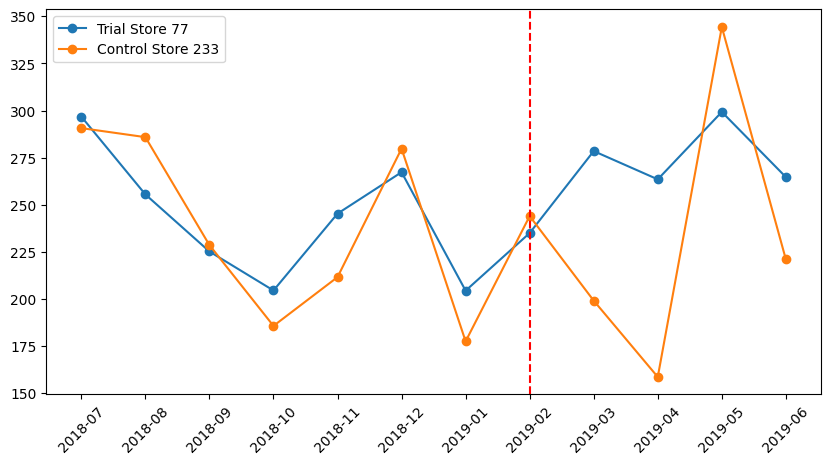

In [62]:
#graphs
#sales graph for store 77
plt.figure(figsize=(10,5))

plt.plot(
    compare_77["YEAR_MONTH"].astype(str),
    compare_77["TOTAL_SALES_TRIAL"],
    marker="o",
    label="Trial Store 77"
)

plt.plot(
    compare_77["YEAR_MONTH"].astype(str),
    compare_77["TOTAL_SALES_CONTROL"],
    marker="o",
    label="Control Store 233"
)

plt.axvline("2019-02",color="red",linestyle="--")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [67]:
#Trial Store 77 experienced higher sales during the trial period compared to its control store.

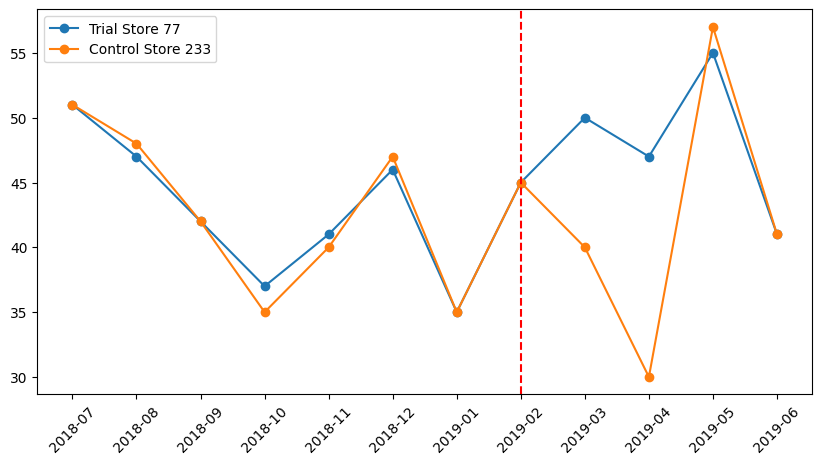

In [63]:
#graphs
#customers graph for store 77
plt.figure(figsize=(10,5))

plt.plot(
    compare_77["YEAR_MONTH"].astype(str),
    compare_77["TOTAL_CUSTOMERS_TRIAL"],
    marker="o",
    label="Trial Store 77"
)

plt.plot(
    compare_77["YEAR_MONTH"].astype(str),
    compare_77["TOTAL_CUSTOMERS_CONTROL"],
    marker="o",
    label="Control Store 233"
)

plt.axvline("2019-02",color="red",linestyle="--")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [66]:
#The increase in sales appears to be driven by an increase in customer count.

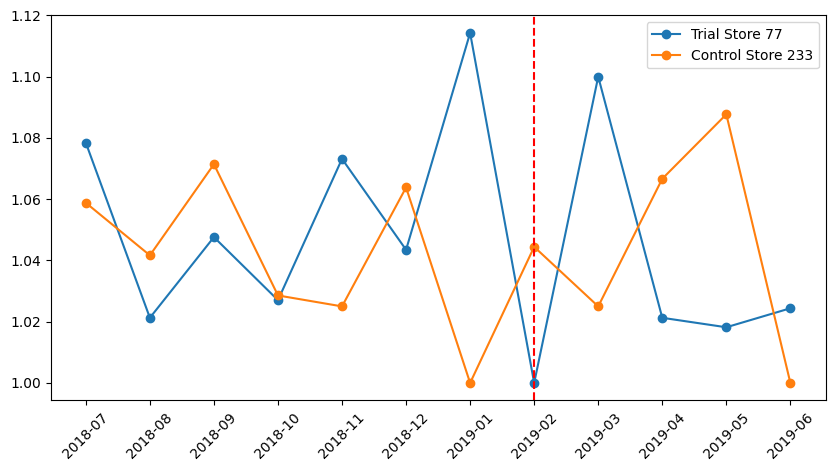

In [64]:
#graphs
#transaction per customers graph for store 77
plt.figure(figsize=(10,5))

plt.plot(
    compare_77["YEAR_MONTH"].astype(str),
    compare_77["TXN_PER_CUSTOMER_TRIAL"],
    marker="o",
    label="Trial Store 77"
)

plt.plot(
    compare_77["YEAR_MONTH"].astype(str),
    compare_77["TXN_PER_CUSTOMER_CONTROL"],
    marker="o",
    label="Control Store 233"
)

plt.axvline("2019-02",color="red",linestyle="--")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [65]:
#The increase was driven by higher purchase frequency.

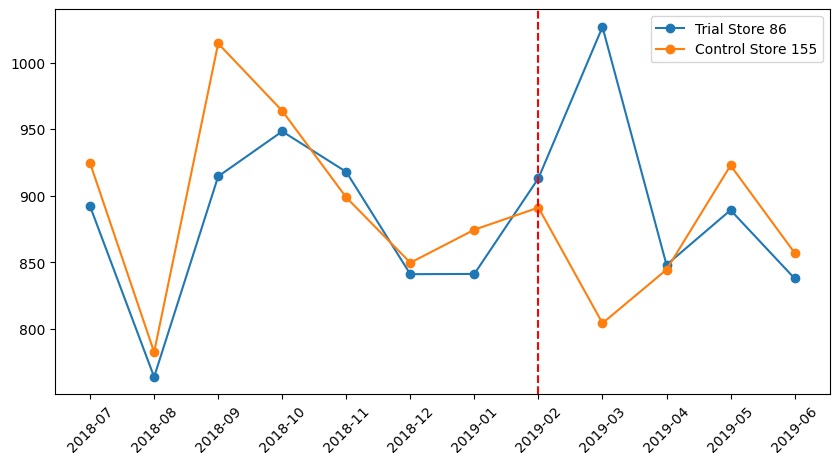

In [69]:
#graphs
#sales graph for store 86
plt.figure(figsize=(10,5))

plt.plot(
    compare_86["YEAR_MONTH"].astype(str),
    compare_86["TOTAL_SALES_TRIAL"],
    marker="o",
    label="Trial Store 86"
)

plt.plot(
    compare_86["YEAR_MONTH"].astype(str),
    compare_86["TOTAL_SALES_CONTROL"],
    marker="o",
    label="Control Store 155"
)

plt.axvline("2019-02",color="red",linestyle="--")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [80]:
#Trial Store 86 experienced higher sales during the trial period compared to its control store.

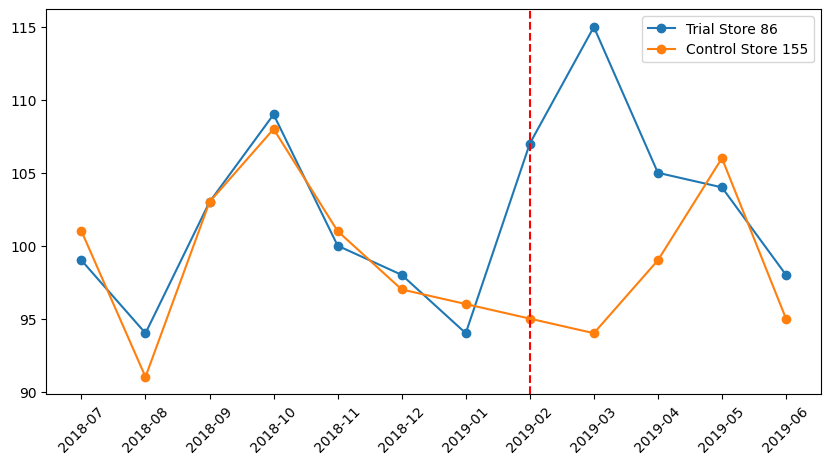

In [70]:
#graphs
#customers graph for store 86
plt.figure(figsize=(10,5))

plt.plot(
    compare_86["YEAR_MONTH"].astype(str),
    compare_86["TOTAL_CUSTOMERS_TRIAL"],
    marker="o",
    label="Trial Store 86"
)

plt.plot(
    compare_86["YEAR_MONTH"].astype(str),
    compare_86["TOTAL_CUSTOMERS_CONTROL"],
    marker="o",
    label="Control Store 155"
)

plt.axvline("2019-02",color="red",linestyle="--")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [79]:
#The increase in sales appears to be driven by an increase in customer count.

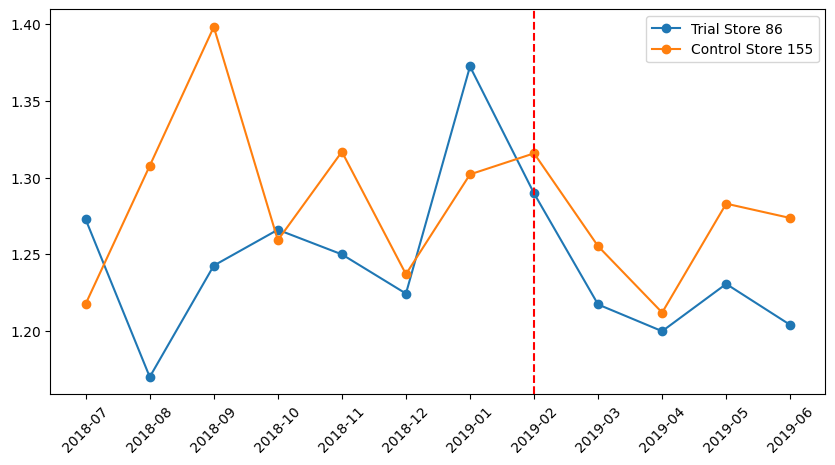

In [71]:
#graphs
#transaction per customers graph for store 86
plt.figure(figsize=(10,5))

plt.plot(
    compare_86["YEAR_MONTH"].astype(str),
    compare_86["TXN_PER_CUSTOMER_TRIAL"],
    marker="o",
    label="Trial Store 86"
)

plt.plot(
    compare_86["YEAR_MONTH"].astype(str),
    compare_86["TXN_PER_CUSTOMER_CONTROL"],
    marker="o",
    label="Control Store 155"
)

plt.axvline("2019-02",color="red",linestyle="--")

plt.legend()

plt.xticks(rotation=45)

plt.show()

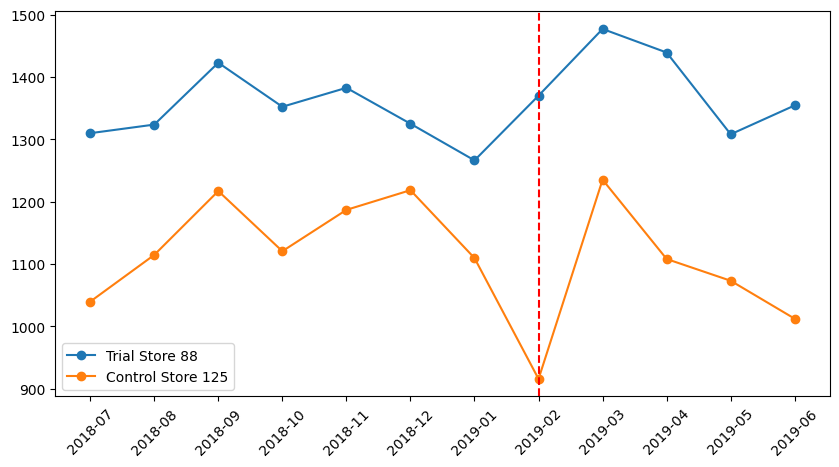

In [73]:
#graphs
#slaes graph for store 88
plt.figure(figsize=(10,5))

plt.plot(
    compare_88["YEAR_MONTH"].astype(str),
    compare_88["TOTAL_SALES_TRIAL"],
    marker="o",
    label="Trial Store 88"
)

plt.plot(
    compare_88["YEAR_MONTH"].astype(str),
    compare_88["TOTAL_SALES_CONTROL"],
    marker="o",
    label="Control Store 125"
)

plt.axvline("2019-02",color="red",linestyle="--")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [78]:
#Trial Store 88 experienced higher sales during the trial period compared to its control store.

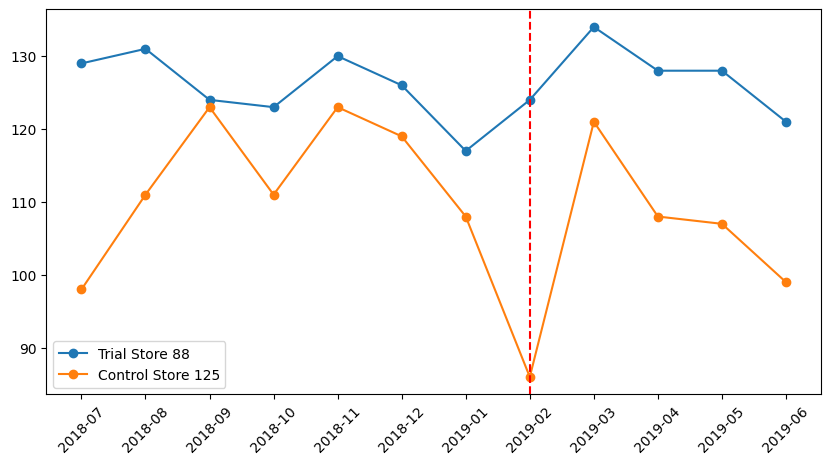

In [74]:
#graphs
#customers graph for store 88
plt.figure(figsize=(10,5))

plt.plot(
    compare_88["YEAR_MONTH"].astype(str),
    compare_88["TOTAL_CUSTOMERS_TRIAL"],
    marker="o",
    label="Trial Store 88"
)

plt.plot(
    compare_88["YEAR_MONTH"].astype(str),
    compare_88["TOTAL_CUSTOMERS_CONTROL"],
    marker="o",
    label="Control Store 125"
)

plt.axvline("2019-02",color="red",linestyle="--")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [77]:
#The increase in sales appears to be driven by an increase in customer count.

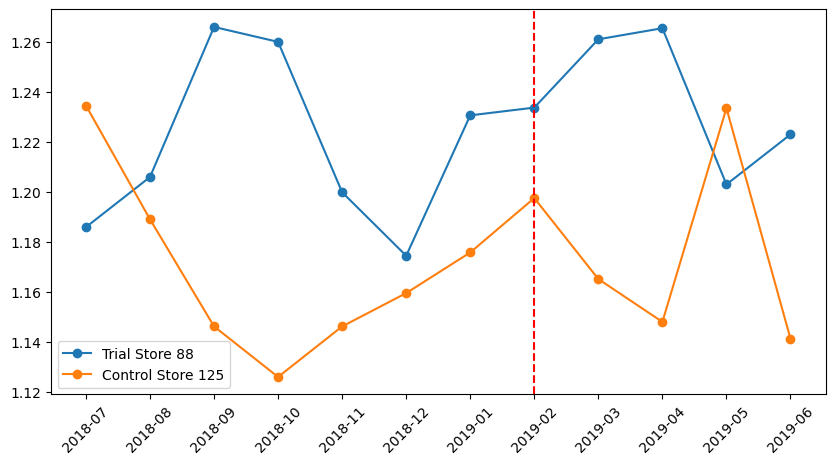

In [75]:
#graphs
#transaction per customers graph for store 88
plt.figure(figsize=(10,5))

plt.plot(
    compare_88["YEAR_MONTH"].astype(str),
    compare_88["TXN_PER_CUSTOMER_TRIAL"],
    marker="o",
    label="Trial Store 88"
)

plt.plot(
    compare_88["YEAR_MONTH"].astype(str),
    compare_88["TXN_PER_CUSTOMER_CONTROL"],
    marker="o",
    label="Control Store 125"
)

plt.axvline("2019-02",color="red",linestyle="--")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [76]:
#The increase was driven by higher purchase frequency.